In [1]:
#data handling(data ko table format mai likhny k liye)
import pandas as pd

In [2]:
#TF-IDF (text ko number mai convert krny wala tool) text ko smart numbers vectors mai badalta rare word sko imporatance
from sklearn.feature_extraction.text import TfidfVectorizer

In [3]:
# Cosine Similarity nikalne ke liye (similarity score calculate karna)
from sklearn.metrics.pairwise import cosine_similarity


In [ ]:
#jobs and required skills
data={
    'job_role':[
        'Data Scientist',
        'DevOps Engineer',
        'Backend Developer',
        'Frontend Developer',
        'Cloud Architect',
        'Machine Learning Engineer',
        'Cybersecurity Analyst',
        'Mobile App Developer'
    ],
'skills':[
     'Python SQL Machine Learning Data Analysis Statistics Pandas',
      'AWS Docker Kubernetes CI/CD Linux Automation Cloud',
      'Java Python SQL APIs Backend Databases Node.js',
      'HTML CSS JavaScript React UI Design Frontend',
      'AWS Cloud Computing Networking Security Architecture Automation',
      'Python Machine Learning Deep Learning TensorFlow PyTorch Statistics',
      'Networking Security Encryption Penetration Testing Linux',
      'Java Kotlin Swift Mobile UI Android iOS'
]
    }




In [8]:
#hm an string mai data isliye rkha hai na k list mai k tdif sentences expect krta haii
df=pd.DataFrame(data)
print(df)

                    job_role  \
0             Data Scientist   
1            DevOps Engineer   
2          Backend Developer   
3         Frontend Developer   
4            Cloud Architect   
5  Machine Learning Engineer   
6      Cybersecurity Analyst   
7       Mobile App Developer   

                                              skills  
0  Python SQL Machine Learning Data Analysis Stat...  
1  AWS Docker Kubernetes CI/CD Linux Automation C...  
2     Java Python SQL APIs Backend Databases Node.js  
3       HTML CSS JavaScript React UI Design Frontend  
4  AWS Cloud Computing Networking Security Archit...  
5  Python Machine Learning Deep Learning TensorFl...  
6  Networking Security Encryption Penetration Tes...  
7            Java Kotlin Swift Mobile UI Android iOS  


In [11]:
print("Please enter at least 3 skills you have (one at a time).")
print("Example: Python, Cloud, Automation, SQL, etc.\n")

skill1=input("Enter skill 1: ")
skill2 = input("Enter skill 2: ")
skill3 = input("Enter skill 3: ")

user_skills=skill1 + " " + skill2 + " " + skill3
print("\nYour combined skills:", user_skills)

Please enter at least 3 skills you have (one at a time).
Example: Python, Cloud, Automation, SQL, etc.

Enter skill 1: Python
Enter skill 2: Cloud
Enter skill 3: Automation

Your combined skills: Python Cloud Automation


In [14]:
all_text=df['skills'].tolist()
all_text.append(user_skills)

vectorizer=TfidfVectorizer()
tfidf_matrix=vectorizer.fit_transform(all_text)
print("TF-IDF Matrix Shape:", tfidf_matrix.shape)
print("\nUnique words found:",vectorizer.get_feature_names_out())

TF-IDF Matrix Shape: (9, 44)

Unique words found: ['analysis' 'android' 'apis' 'architecture' 'automation' 'aws' 'backend'
 'cd' 'ci' 'cloud' 'computing' 'css' 'data' 'databases' 'deep' 'design'
 'docker' 'encryption' 'frontend' 'html' 'ios' 'java' 'javascript' 'js'
 'kotlin' 'kubernetes' 'learning' 'linux' 'machine' 'mobile' 'networking'
 'node' 'pandas' 'penetration' 'python' 'pytorch' 'react' 'security' 'sql'
 'statistics' 'swift' 'tensorflow' 'testing' 'ui']


In [16]:
similarity_scores=cosine_similarity(tfidf_matrix[-1],tfidf_matrix[:-1])
similarity_scores=similarity_scores.flatten()

print("Similarity scores with each job:")
for i in range(len(similarity_scores)):
  print(df['job_role'][i], "i" , round(similarity_scores[i], 3))

Similarity scores with each job:
Data Scientist i 0.137
DevOps Engineer i 0.345
Backend Developer i 0.131
Frontend Developer i 0.0
Cloud Architect i 0.386
Machine Learning Engineer i 0.124
Cybersecurity Analyst i 0.0
Mobile App Developer i 0.0


In [17]:
job_scores={}
for i in range(len(similarity_scores)):
  job_scores[df['job_role'][i]]=similarity_scores[i]

sorted_jobs=sorted(job_scores.items(),key=lambda x: x[1],reverse=True)

In [19]:
# Sirf Top 3 nikalo
top_3 = sorted_jobs[:3]
print("=" * 50)
print("TOP 3 RECOMMENDED CAREER PATHS FOR YOU")
print("=" * 50)

rank=1
for job,score in top_3:
   match_percentage = round(score * 100, 1)
   print(f"{rank}. {job}  —  {match_percentage}% Match")
   rank += 1

TOP 3 RECOMMENDED CAREER PATHS FOR YOU
1. Cloud Architect  —  38.6% Match
2. DevOps Engineer  —  34.5% Match
3. Data Scientist  —  13.7% Match


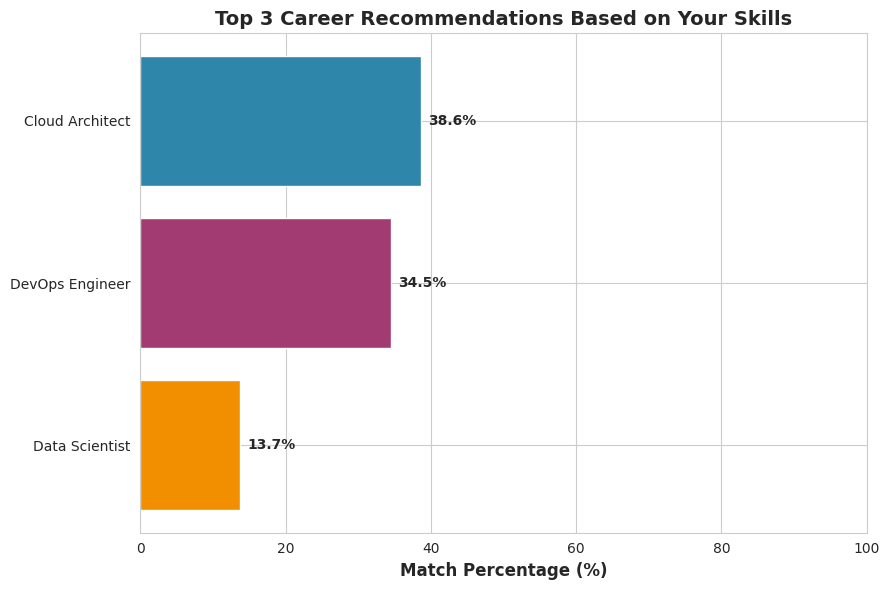

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Top 3 se naam aur scores nikalo
job_names = [item[0] for item in top_3]
job_percentages = [round(item[1] * 100, 1) for item in top_3]

# Bar chart banao
plt.figure(figsize=(9, 6))
bars = plt.barh(job_names, job_percentages, color=['#2E86AB', '#A23B72', '#F18F01'])

plt.xlabel('Match Percentage (%)', fontsize=12, fontweight='bold')
plt.title('Top 3 Career Recommendations Based on Your Skills', fontsize=14, fontweight='bold')
plt.xlim(0, 100)

# Har bar ke aakhir mein percentage number likho
for bar, percentage in zip(bars, job_percentages):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
              f'{percentage}%', va='center', fontweight='bold')

plt.gca().invert_yaxis()  # sabse high score upar dikhaye
plt.tight_layout()
plt.savefig('career_recommendations.png', dpi=300, bbox_inches='tight')
plt.show()

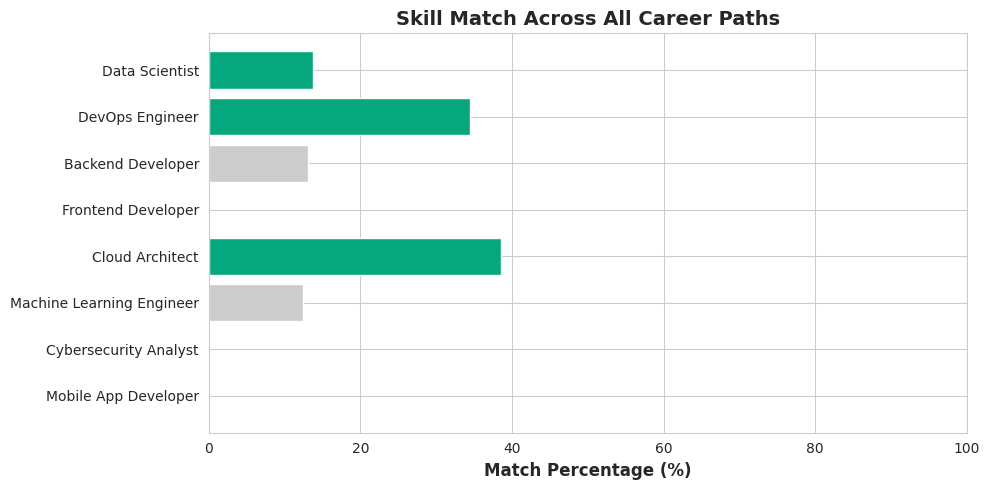

In [21]:
plt.figure(figsize=(10, 5))

all_job_names = df['job_role'].tolist()
all_percentages = [round(s * 100, 1) for s in similarity_scores]

colors = ['#06A77D' if job in job_names else '#CCCCCC' for job in all_job_names]

plt.barh(all_job_names, all_percentages, color=colors)
plt.xlabel('Match Percentage (%)', fontsize=12, fontweight='bold')
plt.title('Skill Match Across All Career Paths', fontsize=14, fontweight='bold')
plt.xlim(0, 100)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('all_jobs_comparison.png', dpi=300, bbox_inches='tight')
plt.show()